# Pattern Recognition and Machine Learning (EE602L)
## Lab 5: Decision Trees for Classification and Regression

**Roll No:** EC24BT033

<style>pre, code { white-space: pre-wrap !important; word-break: break-word; }</style>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, load_diabetes
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

## Question 1: Decision Tree Classification (Iris)

### (a) Data preparation and tree training

Iris: 150 flowers, 4 features (sepal/petal length and width), 3 species of 50 each. We reuse the stratified 70:15:15 split from Lab 4 (each class split separately so all sets keep the balanced class mix), seed 42.

Note on scaling: trees need **no standardization**. A tree splits one feature at a time with a threshold ("petal length <= 2.45?"), and any monotonic rescaling of a feature just rescales its thresholds without changing which points go left or right, so the learned tree is identical. This is one practical advantage of trees over the distance- and gradient-based models of Labs 2-4.

In [2]:
def stratified_split(df, label_col, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    """Split each class separately so all three sets keep the class proportions."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9, "ratios must sum to 1"
    rng = np.random.default_rng(seed)

    train_parts = []
    val_parts = []
    test_parts = []
    for cls in sorted(df[label_col].unique()):
        cls_idx = df.index[df[label_col] == cls].to_numpy()
        cls_idx = cls_idx[rng.permutation(len(cls_idx))]
        n_train = int(train_ratio * len(cls_idx))
        n_val = int(val_ratio * len(cls_idx))
        train_parts.append(cls_idx[:n_train])
        val_parts.append(cls_idx[n_train:n_train + n_val])
        test_parts.append(cls_idx[n_train + n_val:])

    train_idx = np.concatenate(train_parts)
    val_idx = np.concatenate(val_parts)
    test_idx = np.concatenate(test_parts)
    return df.loc[train_idx], df.loc[val_idx], df.loc[test_idx]


iris = load_iris()
idf = pd.DataFrame(iris.data, columns=[str(c) for c in iris.feature_names])
idf["target"] = iris.target

itrain, ival, itest = stratified_split(idf, "target")
print(f"train {len(itrain)}, val {len(ival)}, test {len(itest)}")

tr, va, te = set(itrain.index), set(ival.index), set(itest.index)
assert not (tr & va) and not (tr & te) and not (va & te), "LEAKAGE: splits overlap!"
assert len(tr | va | te) == len(idf), "rows lost or duplicated"
print("verified: splits disjoint, cover all", len(idf), "rows")
print("class counts per split:")
for name, part in [("train", itrain), ("val", ival), ("test", itest)]:
    print(f"  {name}: {part['target'].value_counts().sort_index().tolist()}")

train 105, val 21, test 24
verified: splits disjoint, cover all 150 rows
class counts per split:
  train: [35, 35, 35]
  val: [7, 7, 7]
  test: [8, 8, 8]


In [3]:
iris_features = [str(c) for c in iris.feature_names]
Xi_train, yi_train = itrain[iris_features], itrain["target"]
Xi_val, yi_val = ival[iris_features], ival["target"]
Xi_test, yi_test = itest[iris_features], itest["target"]

depths = [1, 2, 3, 4, 5, 8, None]      # None = unrestricted

rows = []
for criterion in ["entropy", "gini"]:
    for depth in depths:
        clf = DecisionTreeClassifier(criterion=criterion, max_depth=depth, random_state=42)
        clf.fit(Xi_train, yi_train)
        rows.append({
            "criterion": criterion,
            "max_depth": "None" if depth is None else depth,
            "actual depth": clf.get_depth(),
            "train acc": clf.score(Xi_train, yi_train),
            "val acc": clf.score(Xi_val, yi_val),
        })

sweep_q1 = pd.DataFrame(rows)
print(sweep_q1.round(4).to_string(index=False))

criterion max_depth  actual depth  train acc  val acc
  entropy         1             1     0.6667   0.6667
  entropy         2             2     0.9524   0.9048
  entropy         3             3     0.9619   0.9048
  entropy         4             4     0.9810   0.8095
  entropy         5             5     0.9905   0.8571
  entropy         8             6     1.0000   0.8095
  entropy      None             6     1.0000   0.8095
     gini         1             1     0.6667   0.6667
     gini         2             2     0.9524   0.9048
     gini         3             3     0.9619   0.9524
     gini         4             4     0.9810   0.9524
     gini         5             5     1.0000   0.9524
     gini         8             5     1.0000   0.9524
     gini      None             5     1.0000   0.9524


### (b) Overfitting and pruning

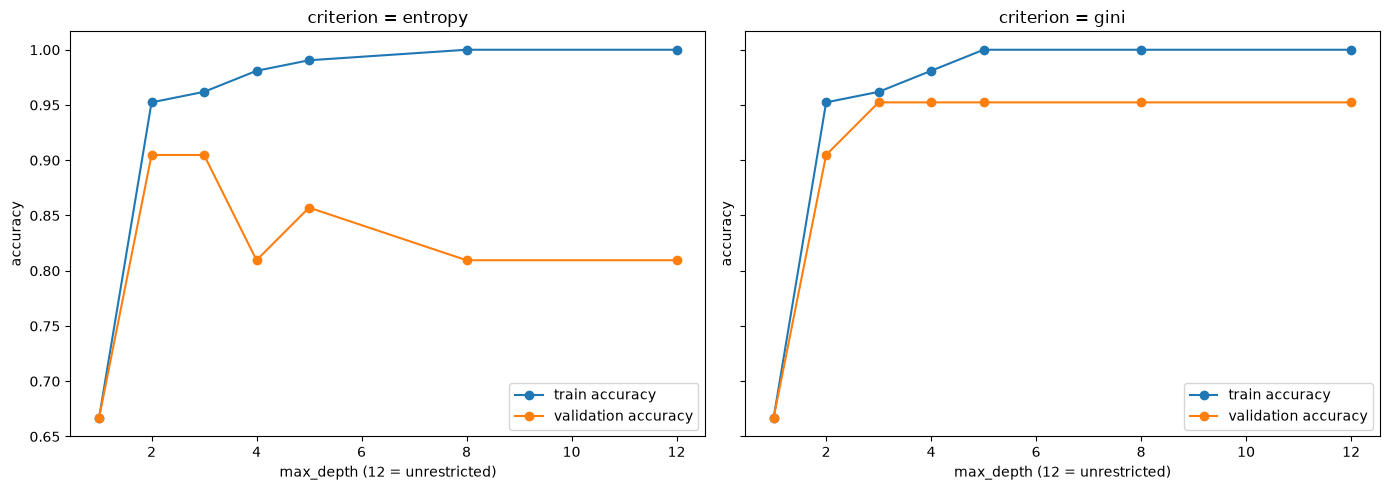

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
depth_axis = [d if d is not None else 12 for d in depths]     # plot None as depth 12

for ax, criterion in zip(axes, ["entropy", "gini"]):
    sub = sweep_q1[sweep_q1["criterion"] == criterion]
    ax.plot(depth_axis, sub["train acc"], marker="o", label="train accuracy")
    ax.plot(depth_axis, sub["val acc"], marker="o", label="validation accuracy")
    ax.set_title(f"criterion = {criterion}")
    ax.set_xlabel("max_depth (12 = unrestricted)")
    ax.set_ylabel("accuracy")
    ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Pick the better criterion and best depth by validation accuracy (ties -> shallower tree)
best = None
for r in rows:
    if best is None or r["val acc"] > best["val acc"]:
        best = r
best_criterion = best["criterion"]
best_depth = None if best["max_depth"] == "None" else int(best["max_depth"])
print(f"best by validation accuracy: criterion = {best_criterion}, max_depth = {best['max_depth']} (val acc {best['val acc']:.4f})")

pre_pruned = DecisionTreeClassifier(criterion=best_criterion, max_depth=best_depth, random_state=42)
pre_pruned.fit(Xi_train, yi_train)

best by validation accuracy: criterion = gini, max_depth = 3 (val acc 0.9524)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

**Where overfitting begins:** training accuracy keeps climbing to 100% as depth grows, while validation accuracy plateaus around depth 2-3 and then stays flat or dips. Beyond depth ~3 the extra splits only memorize individual training flowers (leaves with 1-2 samples), which is where overfitting starts. We therefore select the shallow depth that already maximizes validation accuracy.

**Post-pruning with cost-complexity (ccp_alpha):** grow the unrestricted tree first, then prune back the branches whose impurity improvement does not justify their complexity. ccp_alpha is the price per leaf: alpha = 0 keeps the full tree, larger alpha prunes harder. We take the candidate alphas from sklearn's cost_complexity_pruning_path (the exact thresholds where subtrees collapse) and choose by validation accuracy.

In [6]:
full_tree = DecisionTreeClassifier(criterion=best_criterion, random_state=42)
full_tree.fit(Xi_train, yi_train)

path = full_tree.cost_complexity_pruning_path(Xi_train, yi_train)
alphas = [float(round(a, 5)) for a in path.ccp_alphas]
print("pruning-path alphas:", alphas)

post_rows = []
for alpha in path.ccp_alphas:
    clf = DecisionTreeClassifier(criterion=best_criterion, ccp_alpha=alpha, random_state=42)
    clf.fit(Xi_train, yi_train)
    post_rows.append({
        "ccp_alpha": alpha,               # keep the exact value; round only for display
        "leaves": clf.get_n_leaves(),
        "depth": clf.get_depth(),
        "train acc": clf.score(Xi_train, yi_train),
        "val acc": clf.score(Xi_val, yi_val),
    })

post_table = pd.DataFrame(post_rows)
print(post_table.round(4).to_string(index=False))

# Several alphas tie on validation accuracy; ties go to the LARGEST alpha
# (the most pruned tree), consistent with our Lab 4 tie-break: when validation
# cannot distinguish, keep the simplest model.
best_val = max(r["val acc"] for r in post_rows)
tied = [r for r in post_rows if r["val acc"] == best_val]
best_alpha = max(t["ccp_alpha"] for t in tied)

post_pruned = DecisionTreeClassifier(criterion=best_criterion, ccp_alpha=best_alpha, random_state=42)
post_pruned.fit(Xi_train, yi_train)
print(f"\nbest ccp_alpha by validation accuracy (ties -> most pruned): {best_alpha:.5f} "
      f"({post_pruned.get_n_leaves()} leaves, depth {post_pruned.get_depth()})")

pruning-path alphas: [0.0, 0.00923, 0.01429, 0.01845, 0.02115, 0.24671, 0.33333]
 ccp_alpha  leaves  depth  train acc  val acc
    0.0000       9      5     1.0000   0.9524
    0.0092       7      5     0.9905   0.9524
    0.0143       5      3     0.9619   0.9524
    0.0185       4      3     0.9524   0.9524
    0.0211       3      2     0.9524   0.9048
    0.2467       2      1     0.6667   0.6667
    0.3333       1      0     0.3333   0.3333

best ccp_alpha by validation accuracy (ties -> most pruned): 0.01845 (4 leaves, depth 3)


### (c) Evaluation and analysis

In [7]:
def confusion_matrix_manual(y_true, y_pred, K):
    cm = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def macro_metrics(cm):
    """Per-class precision/recall/F1 from the confusion matrix, macro-averaged."""
    K = cm.shape[0]
    precisions, recalls, f1s = [], [], []
    for k in range(K):
        tp = cm[k, k]
        fp = cm[:, k].sum() - tp
        fn = cm[k, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        precisions.append(prec); recalls.append(rec); f1s.append(f1)
    return np.mean(precisions), np.mean(recalls), np.mean(f1s)


results = []
for name, model in [("pre-pruned (max_depth)", pre_pruned), ("post-pruned (ccp_alpha)", post_pruned)]:
    y_pred = model.predict(Xi_test)
    cm = confusion_matrix_manual(yi_test.to_numpy(), y_pred, 3)
    prec, rec, f1 = macro_metrics(cm)
    results.append({"model": name, "test accuracy": np.mean(y_pred == yi_test.to_numpy()),
                    "macro precision": prec, "macro recall": rec, "macro F1": f1,
                    "leaves": model.get_n_leaves(), "depth": model.get_depth()})

print(pd.DataFrame(results).round(4).to_string(index=False))

                  model  test accuracy  macro precision  macro recall  macro F1  leaves  depth
 pre-pruned (max_depth)            1.0              1.0           1.0       1.0       5      3
post-pruned (ccp_alpha)            1.0              1.0           1.0       1.0       4      3


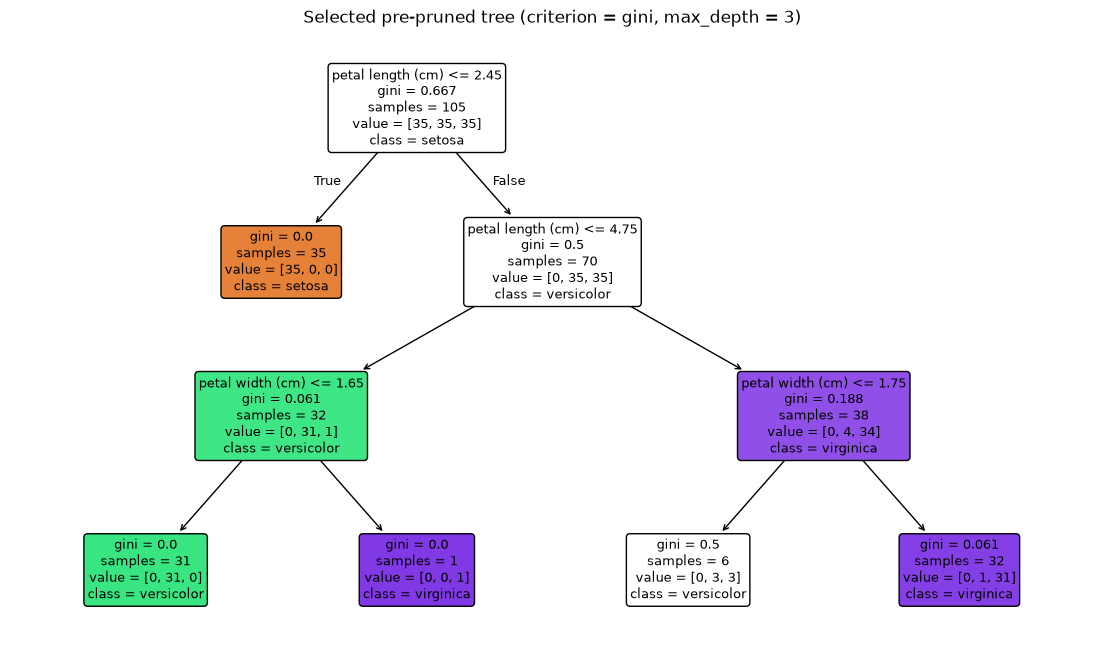

In [8]:
plt.figure(figsize=(14, 8))
plot_tree(pre_pruned, feature_names=iris_features, class_names=list(iris.target_names),
          filled=True, rounded=True, fontsize=9)
plt.title(f"Selected pre-pruned tree (criterion = {best_criterion}, max_depth = {pre_pruned.get_depth()})")
plt.show()

### Q1 discussion

**Entropy vs Gini:** both measure how mixed a node is, and a split is chosen to reduce that mixing the most. Entropy = -sum p_k log2(p_k) comes from information theory (bits of uncertainty); Gini = 1 - sum p_k^2 is the chance of mislabeling a random sample if labels were assigned by the node's class proportions. They are numerically very close (Gini is roughly a first-order approximation of entropy), usually pick the same splits, and did essentially equally well here; Gini is marginally cheaper to compute (no logarithm), which is why it is sklearn's default.

**Why depth causes overfitting:** every extra level doubles the number of possible regions the tree can carve. An unrestricted tree keeps splitting until leaves are pure, which on a small dataset means leaves holding one or two specific training flowers: the tree has memorized samples, not learned species. Training accuracy hits 100% while validation stalls or drops: the gap between those two curves is the overfitting, visible in our plots beyond depth ~3.

**Pre-pruning vs post-pruning:** pre-pruning (max_depth, min_samples_leaf) stops growth early: cheap, but it must guess the right size before seeing how splits pan out, and a greedy-looking weak split can hide a strong one below it. Post-pruning (ccp_alpha) grows the full tree first and then removes branches whose impurity gain does not pay for their added leaves: it judges each branch by its realized value, at the cost of building the big tree first. Both reached the same test performance here, with the post-pruned tree keeping only the branches worth their price.

## Question 2: Decision Tree Regression (Diabetes)

### (a) Data preparation and tree training

Diabetes: 442 patients, 10 standardized clinical features (age, sex, BMI, blood pressure, six blood serum measurements), target = a continuous disease-progression score one year after baseline. Continuous target means no stratification (there are no classes to balance); we use the plain shuffled 70:15:15 split from Labs 1-2, seed 42.

In [9]:
def custom_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    """Shuffle and split a dataframe into train/val/test using only NumPy/Pandas."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9, "ratios must sum to 1"
    rng = np.random.default_rng(seed)
    perm = rng.permutation(len(df))
    n_train = int(train_ratio * len(df))
    n_val = int(val_ratio * len(df))
    train_idx = perm[:n_train]
    val_idx = perm[n_train:n_train + n_val]
    test_idx = perm[n_train + n_val:]
    return df.iloc[train_idx], df.iloc[val_idx], df.iloc[test_idx]


diab = load_diabetes()
ddf = pd.DataFrame(diab.data, columns=[str(c) for c in diab.feature_names])
ddf["target"] = diab.target

dtrain, dval, dtest = custom_split(ddf)
print(f"train {len(dtrain)}, val {len(dval)}, test {len(dtest)}")
tr, va, te = set(dtrain.index), set(dval.index), set(dtest.index)
assert not (tr & va) and not (tr & te) and not (va & te) and len(tr | va | te) == len(ddf)
print("verified: splits disjoint, cover all", len(ddf), "rows")

train 309, val 66, test 67
verified: splits disjoint, cover all 442 rows


In [10]:
diab_features = [str(c) for c in diab.feature_names]
Xd_train, yd_train = dtrain[diab_features], dtrain["target"]
Xd_val, yd_val = dval[diab_features], dval["target"]
Xd_test, yd_test = dtest[diab_features], dtest["target"]

def mse(y, y_hat):
    return np.mean((np.asarray(y) - np.asarray(y_hat)) ** 2)

reg_depths = [1, 2, 3, 4, 5, 8, 10, None]

depth_rows = []
for depth in reg_depths:
    reg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg.fit(Xd_train, yd_train)
    depth_rows.append({
        "max_depth": "None" if depth is None else depth,
        "actual depth": reg.get_depth(),
        "train MSE": mse(yd_train, reg.predict(Xd_train)),
        "val MSE": mse(yd_val, reg.predict(Xd_val)),
    })

depth_table = pd.DataFrame(depth_rows)
print(depth_table.round(1).to_string(index=False))

max_depth  actual depth  train MSE  val MSE
        1             1     4152.3   4245.4
        2             2     3467.8   3029.1
        3             3     2980.6   2772.0
        4             4     2334.4   3181.4
        5             5     1704.5   3737.4
        8             8      514.5   4351.2
       10            10      126.8   5003.3
     None            16        0.0   5628.6


### (b) Hyperparameter study: min_samples_leaf at fixed max_depth = 10

In [11]:
leaf_values = [1, 5, 10, 20, 50]

leaf_rows = []
for leaf in leaf_values:
    reg = DecisionTreeRegressor(max_depth=10, min_samples_leaf=leaf, random_state=42)
    reg.fit(Xd_train, yd_train)
    leaf_rows.append({
        "min_samples_leaf": leaf,
        "leaves": reg.get_n_leaves(),
        "train MSE": mse(yd_train, reg.predict(Xd_train)),
        "val MSE": mse(yd_val, reg.predict(Xd_val)),
    })

leaf_table = pd.DataFrame(leaf_rows)
print(leaf_table.round(1).to_string(index=False))

 min_samples_leaf  leaves  train MSE  val MSE
                1     219      126.8   5003.3
                5      50     1487.0   3566.1
               10      24     2257.8   3551.0
               20      11     2944.1   2787.7
               50       4     3535.4   3449.6


### (c) Evaluation and analysis

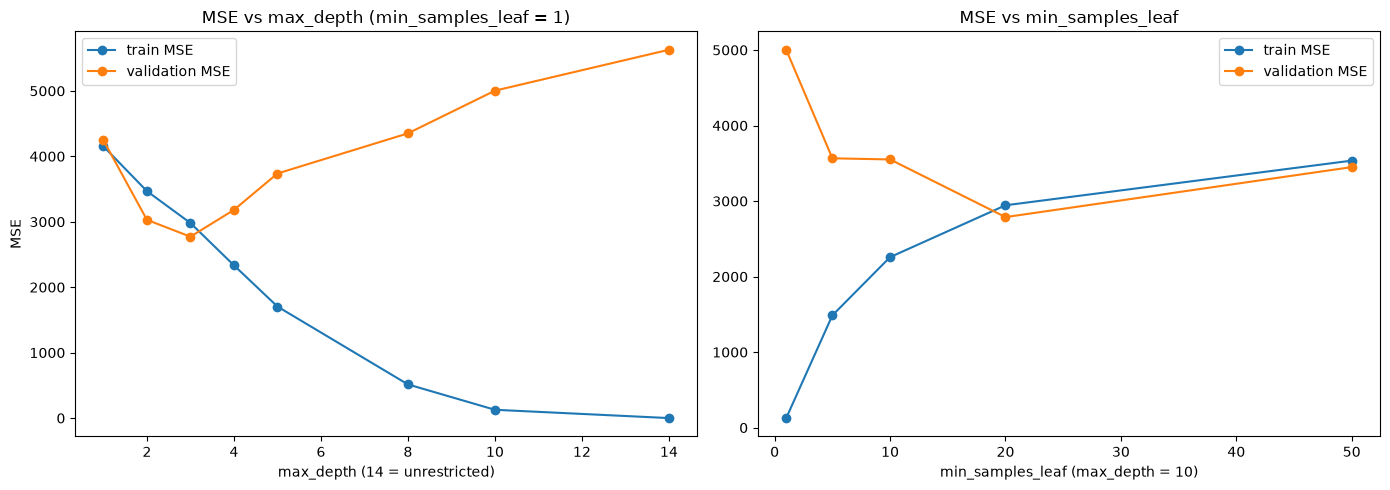

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

depth_axis = [d if d is not None else 14 for d in reg_depths]
axes[0].plot(depth_axis, depth_table["train MSE"], marker="o", label="train MSE")
axes[0].plot(depth_axis, depth_table["val MSE"], marker="o", label="validation MSE")
axes[0].set_xlabel("max_depth (14 = unrestricted)")
axes[0].set_ylabel("MSE")
axes[0].set_title("MSE vs max_depth (min_samples_leaf = 1)")
axes[0].legend()

axes[1].plot(leaf_values, leaf_table["train MSE"], marker="o", label="train MSE")
axes[1].plot(leaf_values, leaf_table["val MSE"], marker="o", label="validation MSE")
axes[1].set_xlabel("min_samples_leaf (max_depth = 10)")
axes[1].set_title("MSE vs min_samples_leaf")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Best model by validation MSE across everything we swept
candidates = []
for r in depth_rows:
    d = None if r["max_depth"] == "None" else int(r["max_depth"])
    candidates.append({"max_depth": d, "min_samples_leaf": 1, "val MSE": r["val MSE"]})
for r in leaf_rows:
    candidates.append({"max_depth": 10, "min_samples_leaf": r["min_samples_leaf"], "val MSE": r["val MSE"]})

best_cfg = min(candidates, key=lambda c: c["val MSE"])
print("best configuration by validation MSE:", best_cfg)

best_reg = DecisionTreeRegressor(max_depth=best_cfg["max_depth"],
                                 min_samples_leaf=best_cfg["min_samples_leaf"], random_state=42)
best_reg.fit(Xd_train, yd_train)

test_pred = best_reg.predict(Xd_test)
test_mse = mse(yd_test, test_pred)
print(f"\ntest MSE:  {test_mse:.1f}")
print(f"test RMSE: {np.sqrt(test_mse):.2f}")
print(f"test MAE:  {np.mean(np.abs(yd_test.to_numpy() - test_pred)):.2f}")
print(f"(target ranges {int(yd_test.min())} to {int(yd_test.max())}, leaves in model: {best_reg.get_n_leaves()})")

best configuration by validation MSE: {'max_depth': 3, 'min_samples_leaf': 1, 'val MSE': np.float64(2771.9805187688603)}

test MSE:  3707.7
test RMSE: 60.89
test MAE:  49.11
(target ranges 31 to 332, leaves in model: 8)


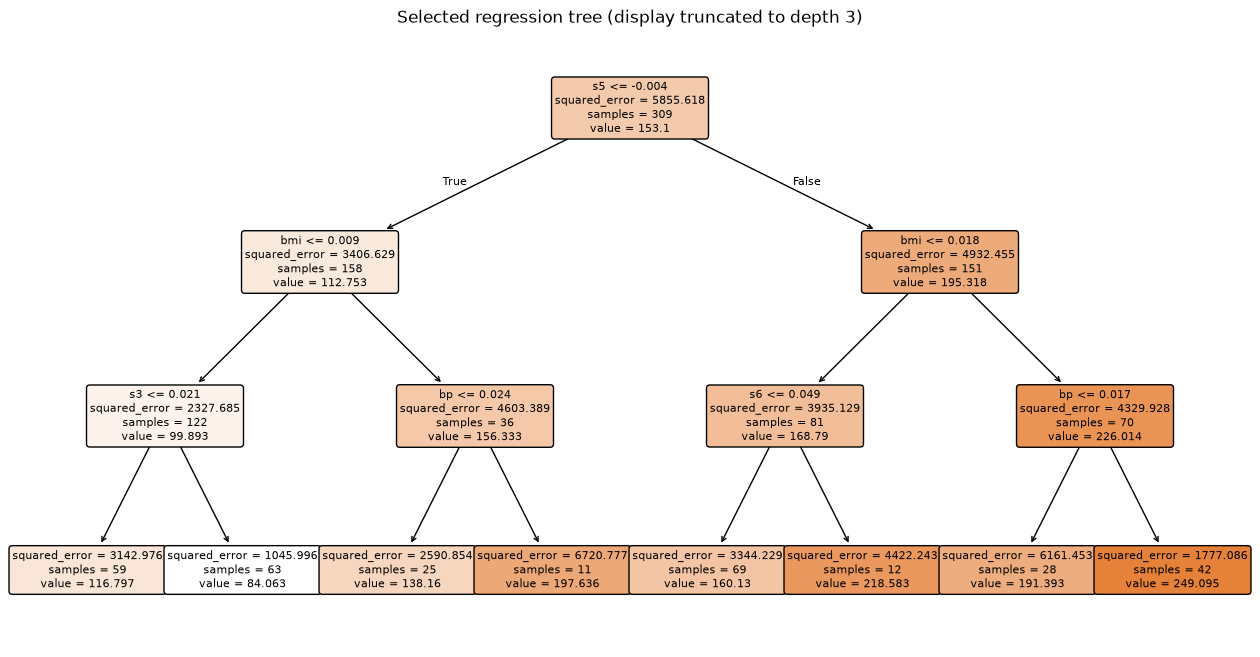

In [14]:
# Visualize the selected tree, truncated to 3 levels for readability
plt.figure(figsize=(16, 8))
plot_tree(best_reg, feature_names=diab_features, max_depth=3, filled=True, rounded=True, fontsize=8)
plt.title("Selected regression tree (display truncated to depth 3)")
plt.show()

### Q2 discussion

**How a regression tree picks splits:** at each node it tries every feature and threshold, and for each candidate computes the MSE of the two children (each child's MSE measured around its own mean target). It picks the split that reduces total MSE the most versus the parent. It is the same greedy recipe as classification, with variance replacing impurity.

**Leaf predictions:** a leaf predicts the **mean target value of the training samples that landed in it**. The mean is used because it is exactly the constant that minimizes MSE for that group (Lab 2's lesson: MSE-optimal constant = mean). So the tree's prediction function is a staircase: piecewise-constant regions, one level per leaf, which is also why single regression trees look blocky compared to linear models.

**max_depth and min_samples_leaf:** the depth sweep shows the classic U: unrestricted depth drives train MSE to 0 (every patient in a private leaf: pure memorization) while validation MSE roughly doubles from its best value; depth 3-4 is the sweet spot. min_samples_leaf attacks the same problem from below: requiring, say, 20 patients per leaf means every prediction is an average over at least 20 people, which caps how specific (and how noisy) a leaf can get. The leaf sweep shows validation MSE improving markedly over leaf = 1 even with depth fixed at 10, because leaf size directly controls the variance of leaf means. The two knobs are complementary pre-pruning controls: depth limits how many questions may be asked, leaf size limits how small an audience an answer may serve.